# 📁 Stage 1: Case Base Construction
## Sistem CBR Putusan Pengadilan - Pidana Umum Penggelapan

**Tujuan Notebook ini:**
- Membaca seluruh file PDF putusan pengadilan dari folder `data/raw/`
- Mengekstrak teks menggunakan `pdfplumber`
- Membersihkan teks (cleaning)
- Menyimpan hasil ke `data/processed/cleaned_cases.csv`

**Konsep CBR:**
> Case Base adalah kumpulan kasus historis yang sudah direpresentasikan dan disimpan. Tahap ini membangun fondasi dari sistem CBR.

---

In [10]:
import sys
import os

sys.path.append(os.path.join(os.getcwd(), "..", "src"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from preprocessing import read_pdf, clean_text, process_all_pdfs

print("Library berhasil diimport!")
print(f"Python version: {sys.version}")

Library berhasil diimport!
Python version: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]


## Step 1.1: Konfigurasi Path

In [11]:
# =====================================================
# Konfigurasi path project
# =====================================================

# Sesuaikan dengan lokasi project Anda
BASE_DIR = Path('..').resolve()
DATA_RAW = BASE_DIR / 'data' / 'raw'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
OUTPUT_CSV = DATA_PROCESSED / 'cleaned_cases.csv'

print(f'Base Dir    : {BASE_DIR}')
print(f'Data Raw    : {DATA_RAW}')
print(f'Data Processed: {DATA_PROCESSED}')
print(f'Output CSV  : {OUTPUT_CSV}')

# Cek berapa PDF yang ada di folder raw
pdf_files = list(DATA_RAW.glob('*.pdf'))
print(f'\n📂 Jumlah PDF ditemukan: {len(pdf_files)}')

if pdf_files:
    for f in pdf_files[:5]:
        print(f'   - {f.name}')
    if len(pdf_files) > 5:
        print(f'   ... dan {len(pdf_files) - 5} file lainnya')

Base Dir    : D:\TUGASSSSSSSSSSSSSSSSSSS\PK
Data Raw    : D:\TUGASSSSSSSSSSSSSSSSSSS\PK\data\raw
Data Processed: D:\TUGASSSSSSSSSSSSSSSSSSS\PK\data\processed
Output CSV  : D:\TUGASSSSSSSSSSSSSSSSSSS\PK\data\processed\cleaned_cases.csv

📂 Jumlah PDF ditemukan: 106
   - putusan_0372_pdt.g_2016_pa.wsp_20260617144938.pdf
   - putusan_1027_k_pid_2016_20260610214911.pdf
   - putusan_1031_k_pid_2013_20260610220650.pdf
   - putusan_104_k_pid_2024_20260610224929.pdf
   - putusan_1080_k_pid_201_20260610214520.pdf
   ... dan 101 file lainnya


## Step 1.2: Membaca dan Membersihkan PDF

> **Catatan:** Jika folder `data/raw/` belum memiliki file PDF, sistem akan otomatis menggunakan data dummy untuk demonstrasi.

In [12]:
# Proses semua PDF dari folder data/raw/
if len(pdf_files) == 0:
    print("[ERROR] Tidak ada file PDF di folder data/raw/")
    print("Silakan masukkan file PDF putusan MA ke folder data/raw/")
else:
    print(f"Memproses {len(pdf_files)} file PDF asli...")
    df = process_all_pdfs(str(DATA_RAW), str(OUTPUT_CSV))
    print(f"\nDataset berhasil dibuat!")
    print(f"Jumlah kasus: {len(df)}")
    print(f"Kolom: {list(df.columns)}")

2026-06-19 23:08:29,399 - INFO - Ditemukan 106 file PDF


Memproses 106 file PDF asli...


Memproses PDF: 100%|██████████| 106/106 [02:59<00:00,  1.70s/it]
2026-06-19 23:11:29,409 - INFO - Tersimpan 106 kasus -> D:\TUGASSSSSSSSSSSSSSSSSSS\PK\data\processed\cleaned_cases.csv



Dataset berhasil dibuat!
Jumlah kasus: 106
Kolom: ['case_id', 'filename', 'cleaned_text']


## Step 1.3: Preview Data

In [13]:
# Tampilkan 5 baris pertama
print('Preview cleaned_cases.csv:')
df.head()

Preview cleaned_cases.csv:


,case_id,filename,cleaned_text
0,CASE_001,putusan_0372_pdt.g_2016_pa.wsp_20260617144938.pdf,a i s e n o d n i k i l b u p e a r i s g e n ...
1,CASE_002,putusan_1027_k_pid_2016_20260610214911.pdf,a i s e n o d n i k i l b u p e a r i s g e n ...
2,CASE_003,putusan_1031_k_pid_2013_20260610220650.pdf,a i s e n o d n i k i l b u p e a r i s g e n ...
3,CASE_004,putusan_104_k_pid_2024_20260610224929.pdf,a i s e n o d n i k i l b u p e a r i s g e n ...
4,CASE_005,putusan_1080_k_pid_201_20260610214520.pdf,a i s e n o d n i k i l b u p e a r i s g e n ...


In [14]:
# Statistik dasar dataset
print('=' * 50)
print('STATISTIK DATASET')
print('=' * 50)
print(f'Jumlah kasus    : {len(df)}')
print(f'Kolom           : {list(df.columns)}')
print(f'Missing values  :')
print(df.isnull().sum())

# Panjang teks rata-rata
df['panjang_teks'] = df['cleaned_text'].str.len()
print(f'\nPanjang teks rata-rata : {df["panjang_teks"].mean():.0f} karakter')
print(f'Panjang teks min       : {df["panjang_teks"].min()} karakter')
print(f'Panjang teks max       : {df["panjang_teks"].max()} karakter')

STATISTIK DATASET
Jumlah kasus    : 106
Kolom           : ['case_id', 'filename', 'cleaned_text']
Missing values  :
case_id         0
filename        0
cleaned_text    0
dtype: int64

Panjang teks rata-rata : 64129 karakter
Panjang teks min       : 1406 karakter
Panjang teks max       : 248624 karakter


## Step 1.4: Contoh Cleaning Teks

In [15]:
# Demonstrasi fungsi clean_text
teks_contoh = """
MAHKAMAH AGUNG REPUBLIK INDONESIA
Direktori Putusan Mahkamah Agung
putusan.mahkamahagung.go.id

Halaman 1 dari 10

Menimbang bahwa Terdakwa BUDI SANTOSO Bin AHMAD telah didakwa melakukan 
tindak PIDANA PENGGELAPAN sebagaimana diatur dalam Pasal 374 KUHP!!!

- 2 -

Bahwa Terdakwa terbukti bersalah...
"""

hasil_clean = clean_text(teks_contoh)

print('TEKS ASLI (sebelum cleaning):')
print('-' * 40)
print(teks_contoh)
print('\nTEKS SETELAH CLEANING:')
print('-' * 40)
print(hasil_clean)

TEKS ASLI (sebelum cleaning):
----------------------------------------

MAHKAMAH AGUNG REPUBLIK INDONESIA
Direktori Putusan Mahkamah Agung
putusan.mahkamahagung.go.id

Halaman 1 dari 10

Menimbang bahwa Terdakwa BUDI SANTOSO Bin AHMAD telah didakwa melakukan 
tindak PIDANA PENGGELAPAN sebagaimana diatur dalam Pasal 374 KUHP!!!

- 2 -

Bahwa Terdakwa terbukti bersalah...


TEKS SETELAH CLEANING:
----------------------------------------
mahkamah agung menimbang bahwa terdakwa budi santoso bin ahmad telah didakwa melakukan tindak pidana penggelapan sebagaimana diatur dalam pasal 374 kuhp bahwa terdakwa terbukti bersalah...


## Step 1.5: Visualisasi Distribusi Panjang Teks

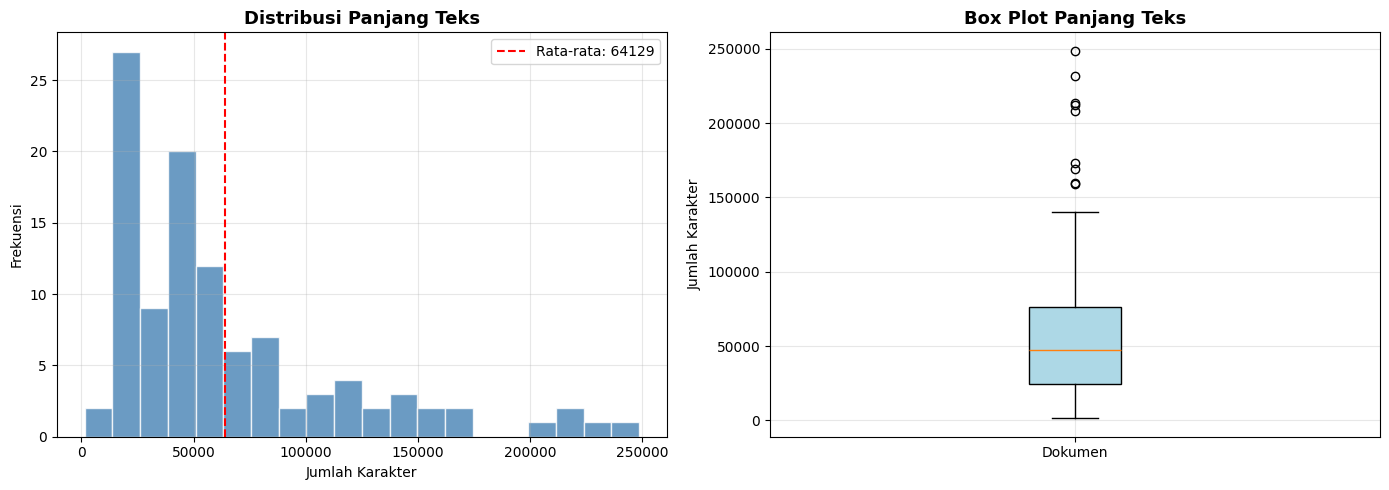


✅ Visualisasi disimpan di: outputs/stage1_distribusi_teks.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram panjang teks
axes[0].hist(df['panjang_teks'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Panjang Teks', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['panjang_teks'].mean(), color='red', linestyle='--',
                label=f'Rata-rata: {df["panjang_teks"].mean():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df['panjang_teks'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Box Plot Panjang Teks', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Karakter')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Dokumen']
)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/stage1_distribusi_teks.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Visualisasi disimpan di: outputs/stage1_distribusi_teks.png')

In [17]:
# Tampilkan contoh 1 kasus lengkap
print('CONTOH KASUS PERTAMA:')
print('=' * 60)
print(f'Case ID  : {df.iloc[0]["case_id"]}')
print(f'Filename : {df.iloc[0]["filename"]}')
print(f'Teks     : {df.iloc[0]["cleaned_text"][:300]}...')

CONTOH KASUS PERTAMA:
Case ID  : CASE_001
Filename : putusan_0372_pdt.g_2016_pa.wsp_20260617144938.pdf
Teks     : a i s e n o d n i k i l b u p e a r i s g e n n o u d g n a i h k a i l m b u a p k e h a r a p u t u s a n i s nomor 372/pdt.g/2016/pa.wsp. m g e n n o demui keadilan berdasarkan ketuhanan yang maha esa pgengadilan agama watansoppeng yang memeriksa dan mengadilid perkara tertentu, pada tingkat pert...
